# EpiCoV EDA for 2020

- Number of sequences: `50,000`
- Collection date range: 1 Jan 2020 to 28 Mar 2020 (13 weeks data)
- Submission date range: 11 Jan 2020 to 17 Apr 2025

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth)

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "~/gcs-buckets"
PLOTS_PATH = "epicov2020_plots/1Jan20_28Mar20_collection/"
YEAR = "2020"

In [3]:
%%time
FILEPATH = os.path.join(DATA_PATH, "1Jan20_15Apr20_collected.csv")
params = {"filepath_or_buffer":FILEPATH, "sep": "," if FILEPATH.endswith(".csv") else "\t"}
df = pd.read_csv(**params)
df.sort_values(by=["Collection date"], inplace=True)
num_rows = 50000
if df.shape[0] > num_rows:
    print(f"Limiting dataset to first {num_rows} rows for testing.")
    df = df.iloc[:num_rows, :]
df.shape, df.info()

Limiting dataset to first 50000 rows for testing.
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 44234 to 61404
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Accession ID                     50000 non-null  object
 1   Submission date                  50000 non-null  object
 2   Virus name                       50000 non-null  object
 3   Collection date                  50000 non-null  object
 4   Location                         50000 non-null  object
 5   Host                             50000 non-null  object
 6   Additional location information  2242 non-null   object
 7   Sampling strategy                1745 non-null   object
 8   Gender                           50000 non-null  object
 9   Patient age                      49999 non-null  object
 10  Patient status                   49985 non-null  object
 11  Last vaccinated                  30 non-null

((50000, 18), None)

In [4]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2020-01-11 00:00:00'), Timestamp('2025-04-17 00:00:00'))

In [5]:
df["submission_yr"] = df["Submission date"].dt.strftime("%Y")
df["submission_yr"].value_counts().sort_index()

submission_yr
2020    37107
2021     9679
2022     2281
2023      805
2024       69
2025       59
Name: count, dtype: int64

In [6]:
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")
df["Collection date"].min(), df["Collection date"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2020-03-28 00:00:00'))

In [7]:
df["collection_yr"] = df["Collection date"].dt.strftime("%Y")
df["collection_yr"].value_counts().sort_index()

collection_yr
2020    50000
Name: count, dtype: int64

Let us validate if `Submission_date` is after the `Collection_date`

In [8]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 20)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [9]:
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

count    50000.000000
mean       218.321900
std        251.492849
min          0.000000
25%         52.000000
50%        136.000000
75%        292.000000
max       1857.000000
Name: collection_to_submission_days, dtype: float64

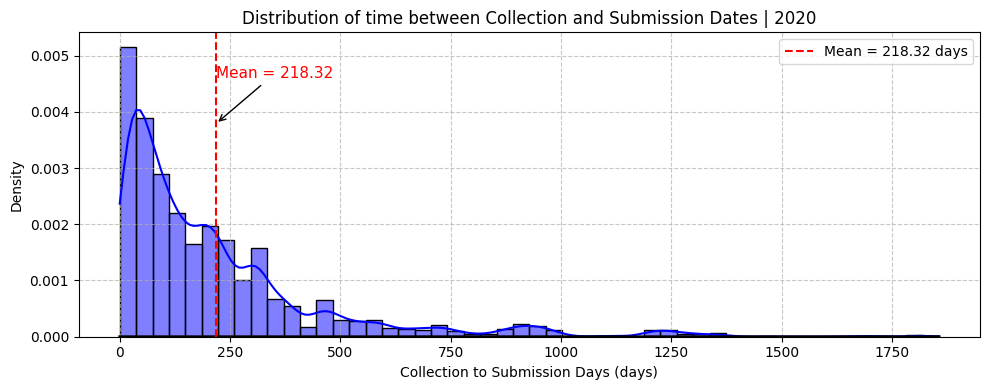

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

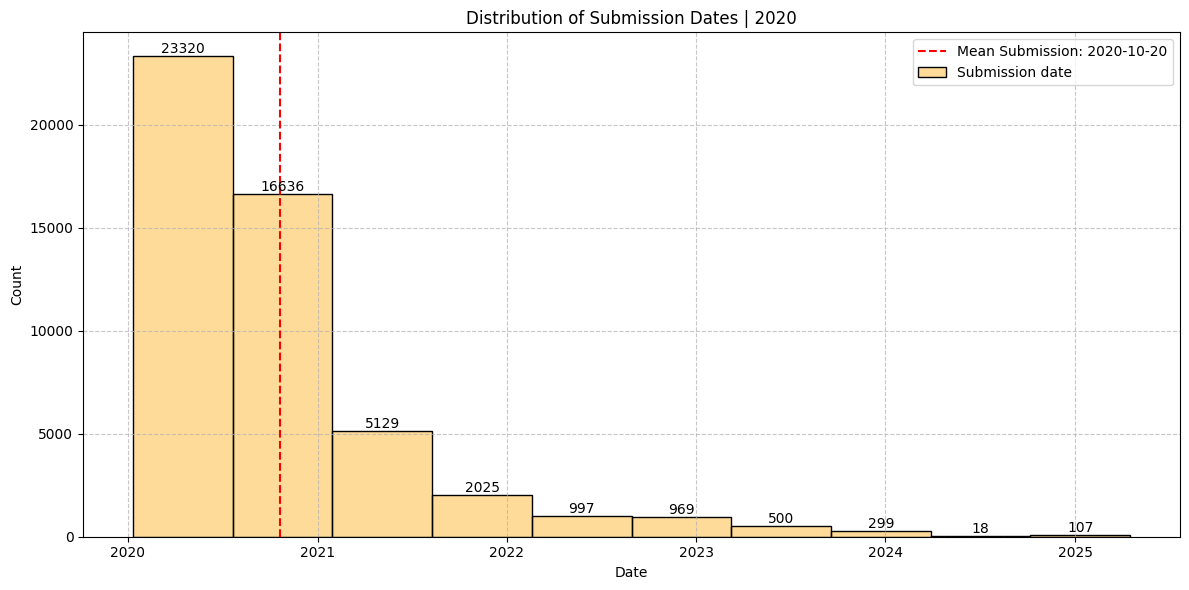

In [11]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

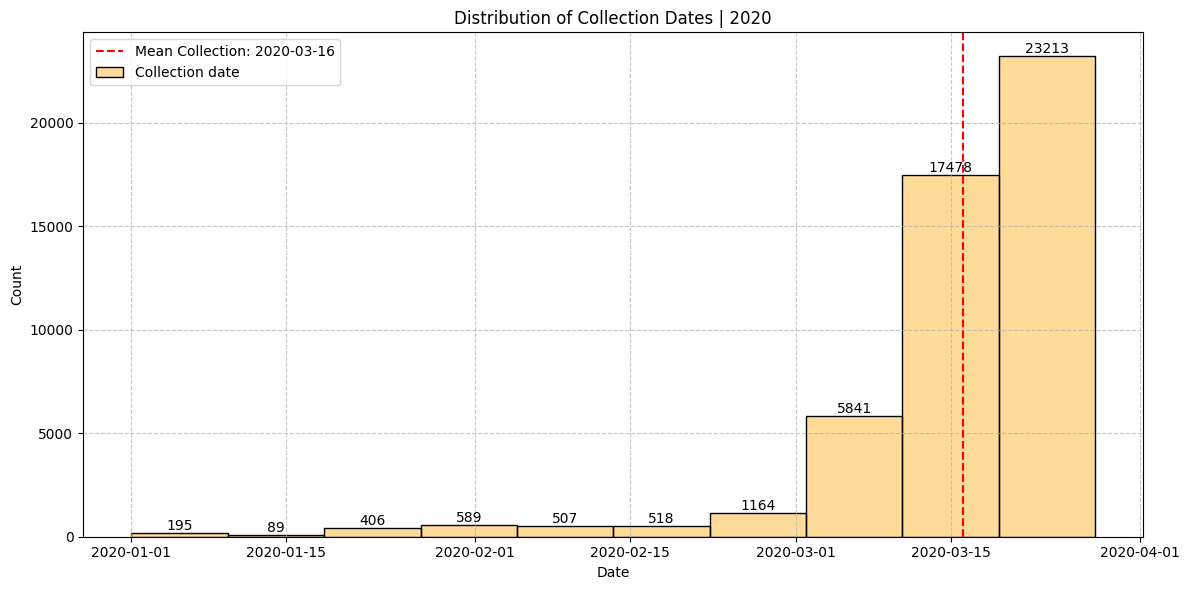

In [12]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

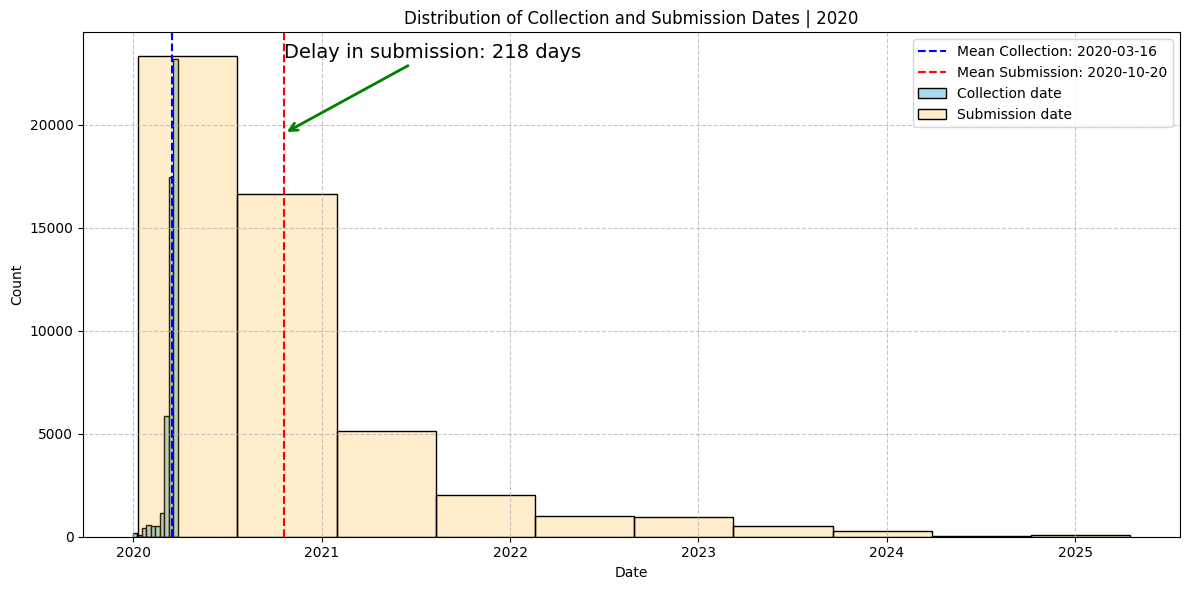

In [13]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [14]:
df["Gender"].value_counts()

Gender
unknown    23759
Male       14242
Female     11994
3.0            1
66.0           1
57.0           1
69.0           1
76.0           1
Name: count, dtype: int64

In [15]:
df["Patient status"].value_counts()

Patient status
unknown                                               45878
Hospitalized                                           1221
Symptomatic                                             501
Released                                                474
Live                                                    456
                                                      ...  
Suspected Corona                                          1
Hospitalized (Deceased)                                   1
Mild infection                                            1
unkown                                                    1
Symptoms indicative of upper respiratory infection        1
Name: count, Length: 69, dtype: int64

In [16]:
df["Patient age"].value_counts()

Patient age
unknown      23595
55             504
56             499
60             483
52             480
             ...  
0.33             1
51-40            1
2020-1984        1
2020-1979        1
0 - 9            1
Name: count, Length: 222, dtype: int64

In [17]:
df[~df["Gender"].isin(["Male", "Female", "unknown"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days
42963,EPI_ISL_4405694,2021-09-22,hCoV-19/Argentina/PAIS-A1026/2020,2020-01-01,South America / Argentina / Buenos Aires / Exa...,Human,NaN,NaN,3.0,Female,...,NaN,Original,NaN,NaN,B.1.499,GH,"(NSP7_S25L,NSP12_P873H,Spike_G181A,NS3_Q57H,NS...",2021,2020,630
25822,EPI_ISL_5944632,2021-11-05,hCoV-19/USA/NY-COV-863/2020,2020-03-18,North America / USA / New York,Human,NaN,NaN,66.0,Male,...,NaN,Original,NaN,NaN,B.1,GH,"(NS3_Q57H,NSP2_T85I,NSP12_P323L,Spike_D614G)",2021,2020,597
25283,EPI_ISL_5944636,2021-11-05,hCoV-19/USA/NY-COV-864/2020,2020-03-19,North America / USA / New York,Human,NaN,NaN,57.0,Male,...,NaN,Original,NaN,NaN,B.1.314,GH,"(NSP2_M405V,Spike_G1219S,NS3_Q57H,NS3_T9I,NSP2...",2021,2020,596
60728,EPI_ISL_5944531,2021-11-05,hCoV-19/USA/NY-COV-866/2020,2020-03-25,North America / USA / New York,Human,NaN,NaN,69.0,Male,...,NaN,Original,Nasopharyngeal swab,NaN,B.1,GH,"(NSP7_S25L,NS3_Q57H,NSP2_T85I,NSP3_M1547I,NSP1...",2021,2020,590
70183,EPI_ISL_5944897,2021-11-05,hCoV-19/USA/NY-COV-867/2020,2020-03-27,North America / USA / New York,Human,NaN,NaN,76.0,Female,...,NaN,Original,Nasopharyngeal swab,NaN,B.1,GH,"(NS3_Q57H,NSP2_T85I,NSP12_P323L,Spike_D614G)",2021,2020,588


In [18]:
# Swap the two values in these rows (Patient age and Patent gender)
for i, row in df[~df["Gender"].isin(["Male", "Female", "unknown"])].iterrows():
    age = row["Patient age"]
    df.at[i, "Patient age"] = row["Gender"]
    df.at[i, "Gender"] = age

In [19]:
df["Gender"].value_counts()

Gender
unknown    23759
Male       14245
Female     11996
Name: count, dtype: int64

## Geographical distribution

Let's see the geographical distribution of various parameters

In [20]:
(print(set([x.split("/")[0] for x in df["Location"].values.tolist()])), df.nunique())

{'South America ', 'North America ', 'Asia ', 'Oceania ', 'Africa ', 'Europe '}


(None,
 Accession ID                       50000
 Submission date                      721
 Virus name                         49998
 Collection date                       86
 Location                            1939
 Host                                   1
 Additional location information      412
 Sampling strategy                     52
 Gender                                 3
 Patient age                          225
 Patient status                        69
 Last vaccinated                        5
 Passage                               72
 Specimen                             196
 Additional host information          119
 Lineage                              409
 Clade                                 11
 AA Substitutions                   14302
 submission_yr                          6
 collection_yr                          1
 collection_to_submission_days       1165
 dtype: int64)

Collate required columns

In [21]:
df1 = df[["Accession ID", "Location", "Gender", "Patient age", "Patient status"]].reset_index(drop=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Location        50000 non-null  object
 2   Gender          50000 non-null  object
 3   Patient age     49999 non-null  object
 4   Patient status  49985 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


Split location into `continent`, `country`, `state` and `city`

In [22]:
df1["continent"], df1["country"], df1["state"], df1["city"] = np.nan, np.nan, np.nan, np.nan

cols = ["continent", "country", "state", "city"]
for i, row in tqdm(df1.iterrows(), desc="Geographical information extraction", total=df1.shape[0]):
    loc = row["Location"]
    locs = [x.strip() for x in loc.split("/")]
    for j in range(min(len(locs),len(cols))):
        df1.loc[i, cols[j]] = locs[j]
df1.drop(columns=["Location"], inplace=True)
df1.info()

Geographical information extraction:   0%|          | 0/50000 [00:00<?, ?it/s]

Geographical information extraction: 100%|██████████| 50000/50000 [00:25<00:00, 1927.46it/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Gender          50000 non-null  object
 2   Patient age     49999 non-null  object
 3   Patient status  49985 non-null  object
 4   continent       50000 non-null  object
 5   country         50000 non-null  object
 6   state           43964 non-null  object
 7   city            11099 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata

In [23]:
df1["country"].nunique()

138

Countrywise population from [Our World in Data](https://ourworldindata.org/population-growth)

In [24]:
df_pop = pd.read_csv(os.path.join(DATA_PATH, "our_world_in_data_population.csv"))
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 75 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   country  256 non-null    object
 1   1950     256 non-null    int64 
 2   1951     256 non-null    int64 
 3   1952     256 non-null    int64 
 4   1953     256 non-null    int64 
 5   1954     256 non-null    int64 
 6   1955     256 non-null    int64 
 7   1956     256 non-null    int64 
 8   1957     256 non-null    int64 
 9   1958     256 non-null    int64 
 10  1959     256 non-null    int64 
 11  1960     256 non-null    int64 
 12  1961     256 non-null    int64 
 13  1962     256 non-null    int64 
 14  1963     256 non-null    int64 
 15  1964     256 non-null    int64 
 16  1965     256 non-null    int64 
 17  1966     256 non-null    int64 
 18  1967     256 non-null    int64 
 19  1968     256 non-null    int64 
 20  1969     256 non-null    int64 
 21  1970     256 non-null    int64 
 22  19

In [25]:
(len(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(8,
 {'Canary Islands',
  'Crimea',
  'Czech Republic',
  'Democratic Republic of the Congo',
  'Saint Martin',
  'Timor-Leste',
  'U.S. Virgin Islands',
  'USA'})

In [26]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)]["country"].value_counts()

country
USA                                 13429
Czech Republic                        124
Canary Islands                         62
Democratic Republic of the Congo       48
U.S. Virgin Islands                     6
Saint Martin                            2
Timor-Leste                             1
Crimea                                  1
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet.

In [27]:
df1["country"] = df1["country"].str.replace("USA", "United States")
df1["country"] = df1["country"].str.replace("Democratic Republic of the Congo", "Democratic Republic of Congo")
df1["country"] = df1["country"].str.replace("Timor-Leste", "East Timor")

In [28]:
df_pop["country"] = df_pop["country"].str.replace("Czechia", "Czech Republic")
df_pop["country"] = df_pop["country"].str.replace("United States Virgin Islands", "U.S. Virgin Islands")
df_pop["country"] = df_pop["country"].str.replace("Saint Martin (French part)", "Saint Martin")
df_pop["country"] = df_pop["country"].str.replace("Bahamas", "The Bahamas")

In [29]:
countries = df1["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(138,
 [{'country': 'United States'}, {'country': 'China'}, {'country': 'France'}])

In [30]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)].shape[0], df1[df1["country"].isin(focus)]["country"].value_counts()

(63,
 country
 Canary Islands    62
 Crimea             1
 Name: count, dtype: int64)

Population of Canary Islands is part of that of Spain - how to deal?

In [31]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df1[df1["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country][YEAR].values[0]
        x["population"] = int(pop)
    elif country in ["Canary Islands","Crimea"]:
        x["population"] = float("NaN")
country_meta[:3]

Filling population data: 100%|██████████| 138/138 [00:00<00:00, 161.09it/s]


[{'country': 'United States',
  'continent': 'North America',
  'population': 339436106},
 {'country': 'China', 'continent': 'Asia', 'population': 1426106040},
 {'country': 'France', 'continent': 'Europe', 'population': 65905226}]

Collect only entries where population is non-zero => exclude Canary Islands as of now

In [32]:
skip_countries = ["Canary Islands", "Crimea"]
df2 = df1[~df1["country"].isin(skip_countries)]
df1.shape, df2.shape

((50000, 8), (49937, 8))

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [33]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Canary Islands","Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((136, 3), (0, 3))

In [34]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Africa (UN)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas (UN)',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Asia (UN)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Timor',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',

In [35]:
exclude = ["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)",
            "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)",
            "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions",
            "Less developed regions, excluding China", "Less developed regions, excluding least developed countries",
            "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)",
            "Small island developing states (SIDS)", "Upper-middle-income countries"]
df_pop = df_pop[~df_pop["country"].isin(exclude)]
df_pop["country"].nunique()

237

In [36]:
df_merged = pd.merge(df_country, df_pop[["country", "2020"]], on="country", how="right")
df_merged.rename(columns={"2020": "population_2020"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          237 non-null    object
 1   continent        136 non-null    object
 2   population_2020  237 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.7+ KB


In [37]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         136 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.5+ KB


In [38]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [39]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2020,country_standard,continent_x
14,The Bahamas,NaN,395827,The Bahamas,Unknown
30,Brunei,Asia,447365,Brunei,Unknown
54,Democratic Republic of Congo,Africa,95989947,Democratic Republic of Congo,Unknown
59,East Timor,Asia,1326002,East Timor,Unknown
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
162,Palestine,Asia,5069642,Palestine,Unknown
174,Russia,Europe,146371239,Russia,Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown


In [40]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [41]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', nan], dtype=object),
 array(['Asia', 'Europe', 'Africa', 'Oceania', 'North America',
        'South America', 'Unknown'], dtype=object))

In [42]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2020,country_standard,continent_x
14,The Bahamas,NaN,395827,The Bahamas,Unknown
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


In [43]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 10: Aruba - South America vs North America
Mismatch at index 13: Azerbaijan - Europe vs Asia
Mismatch at index 51: Curacao - South America vs North America
Mismatch at index 52: Cyprus - Europe vs Asia
Mismatch at index 180: Saint Martin - North America vs Europe


We do the following assignment (based on Google search):

- `Aruba` is in `South America`
- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`
- `Saint Martin` is in `North America`

In [44]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Aruba"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Saint Martin"][0]), "continent_x"] = "North America"

In [45]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           237 non-null    object
 1   continent         230 non-null    object
 2   population_2020   237 non-null    int64 
 3   country_standard  237 non-null    object
 4   continent_x       237 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.4+ KB


6 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [46]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2020,country_standard,continent_x
14,The Bahamas,NaN,395827,The Bahamas,Unknown
111,Kosovo,NaN,1751372,Kosovo,Unknown
136,Micronesia (country),NaN,110883,Micronesia (country),Unknown
177,Saint Helena,NaN,5404,Saint Helena,Unknown
192,Sint Maarten (Dutch part),NaN,40985,Sint Maarten (Dutch part),Unknown
229,Vatican,NaN,521,Vatican,Unknown
233,Western Sahara,NaN,549312,Western Sahara,Unknown


Let's ignore these regions for now.

In [47]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

In [48]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 230 entries, 0 to 236
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           230 non-null    object
 1   continent         230 non-null    object
 2   population_2020   230 non-null    int64 
 3   country_standard  230 non-null    object
dtypes: int64(1), object(3)
memory usage: 9.0+ KB


In [49]:
df_merged[["country", "continent", "country_standard"]].to_csv(os.path.join(DATA_PATH, "country_continent_map.csv"), index=False)

In [50]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    f"population_{YEAR}": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2020,country_standard
226,Wallis and Futuna,Oceania,11602,Wallis and Futuna
227,Yemen,Asia,36134822,Yemen
228,Zambia,Africa,19059354,Zambia
229,Zimbabwe,Africa,15526837,Zimbabwe
230,Antarctica,Antarctica,0,Antarctica


In [51]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        df_merged.loc[i, "num_entries"] = df2[df2["country"]==country].shape[0]
df_merged["num_entries"].describe()

count      136.000000
mean       367.183824
std       1418.655729
min          1.000000
25%          6.000000
50%         18.000000
75%        139.500000
max      13429.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [52]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged[f"population_{YEAR}"] / 1e5)
df_merged.head()

,country,continent,population_2020,country_standard,num_entries,num_entries_per_lakh
0,Afghanistan,Asia,39068933,Afghanistan,NaN,NaN
1,Albania,Europe,2871900,Albania,NaN,NaN
2,Algeria,Africa,44042041,Algeria,12.0,0.027247
3,American Samoa,Oceania,49732,American Samoa,NaN,NaN
4,Andorra,Europe,77343,Andorra,1.0,1.292942


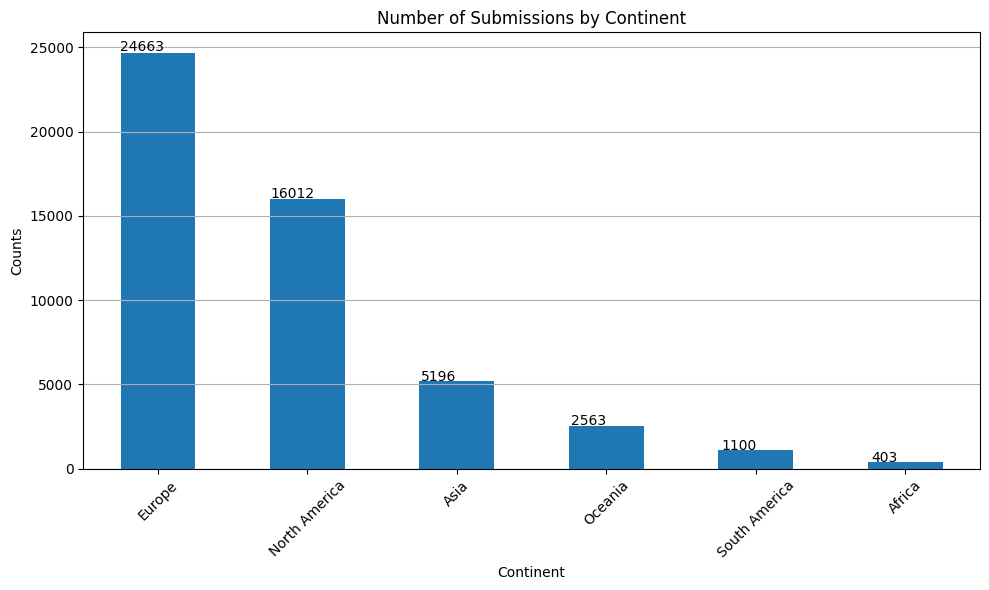

In [53]:
# Plot the bar chart
ax = df2["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [54]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    136.000000
mean      -0.479367
std        0.994383
min       -2.467981
25%       -1.218549
50%       -0.530710
75%        0.314194
max        2.415390
Name: log_num_entries_per_lakh, dtype: float64

In [55]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    136.000000
mean       1.988614
std        0.994383
min        0.000000
25%        1.249432
50%        1.937271
75%        2.782175
max        4.883371
Name: log_num_entries_per_lakh, dtype: float64

In [56]:
# Fill NaN values with a sentinel value (e.g., 0) for visualization purposes
df_merged = col_fillna(df_merged, "log_num_entries_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title=f'Submissions per Lakh Population (World) | Log 10 Scale | {YEAR}',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            f'population_{YEAR}': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Plot per‐continent maps

In [57]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title=f'Submissions per 1 Lakh Population by Continent | Log 10 Scale | {YEAR}',
                           label='Submissions/Lakh (Log 10)',
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

#### A.2. Gender distribution across countries

Let's next look at the gender distribution across countries again grouped by continents

In [58]:
df_merged["gender_m_per_lakh"], df_merged["gender_f_per_lakh"], df_merged["gender_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "gender_m_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Male")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_f_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Female")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_u_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "unknown")].shape[0])/(row[f"population_{YEAR}"] / 1e5)

Convert to log 10 scale to show variation

In [59]:
df_merged["log_gender_m_per_lakh"] = np.log10(df_merged["gender_m_per_lakh"].replace(0, np.nan))
df_merged["log_gender_m_per_lakh"].describe()

count    115.000000
mean      -0.843014
std        0.975956
min       -3.371071
25%       -1.517033
50%       -0.915233
75%       -0.100773
max        2.109784
Name: log_gender_m_per_lakh, dtype: float64

In [60]:
sign = -1 if df_merged["log_gender_m_per_lakh"].min() < 0 else 1
df_merged["log_gender_m_per_lakh"] = df_merged["log_gender_m_per_lakh"] + (df_merged["log_gender_m_per_lakh"].min() * sign)
df_merged["log_gender_m_per_lakh"].describe()

count    115.000000
mean       2.528057
std        0.975956
min        0.000000
25%        1.854038
50%        2.455838
75%        3.270297
max        5.480855
Name: log_gender_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each gender. First we look at a zoomed out view of the whole world

In [61]:
# World map - distribution of males
df_merged = col_fillna(df_merged, "log_gender_m_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.03, "#b3d1e6"],
    [0.06, "#9ecae1"],
    [0.12, "#6bb8d6"],
    [0.25, "#3182bd"],
    [0.5, "#08519c"],
    [1.0, "#08306b"]      # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_gender_m_per_lakh",
                       color_scale=male_scale,
                       title=f"Number of submissions from Males per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Males/1 lakh (Log 10)",
                       hover_data={
                            'gender_m_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we do for the entries submitted by females

In [62]:
df_merged["log_gender_f_per_lakh"] = np.log10(df_merged["gender_f_per_lakh"].replace(0, np.nan))
df_merged["log_gender_f_per_lakh"].describe()

count    109.000000
mean      -0.924842
std        0.988699
min       -3.330406
25%       -1.642118
50%       -1.038704
75%       -0.290897
max        2.114360
Name: log_gender_f_per_lakh, dtype: float64

In [63]:
sign = -1 if df_merged["log_gender_f_per_lakh"].min() < 0 else 1
df_merged["log_gender_f_per_lakh"] = df_merged["log_gender_f_per_lakh"] + (df_merged["log_gender_f_per_lakh"].min() * sign)
df_merged["log_gender_f_per_lakh"].describe()

count    109.000000
mean       2.405564
std        0.988699
min        0.000000
25%        1.688288
50%        2.291702
75%        3.039509
max        5.444766
Name: log_gender_f_per_lakh, dtype: float64

In [64]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_f_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_f_per_lakh",
                       color_scale=female_scale,
                       title=f"Number of submissions from Females per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Females/1 lakh (Log 10)",
                       hover_data={
                            'gender_f_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [65]:
df_merged["log_gender_u_per_lakh"] = np.log10(df_merged["gender_u_per_lakh"].replace(0, np.nan))
df_merged["log_gender_u_per_lakh"].describe()

count    90.000000
mean     -0.937127
std       1.096876
min      -3.301841
25%      -1.963523
50%      -0.802652
75%      -0.178335
max       1.163140
Name: log_gender_u_per_lakh, dtype: float64

In [66]:
sign = -1 if df_merged["log_gender_u_per_lakh"].min() < 0 else 1
df_merged["log_gender_u_per_lakh"] = df_merged["log_gender_u_per_lakh"] + (df_merged["log_gender_u_per_lakh"].min() * sign)
df_merged["log_gender_u_per_lakh"].describe()

count    90.000000
mean      2.364715
std       1.096876
min       0.000000
25%       1.338319
50%       2.499189
75%       3.123506
max       4.464981
Name: log_gender_u_per_lakh, dtype: float64

In [67]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_u_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],  # very light tan
    [0.01, "#fdd49e"],   # light tan-orange
    [0.05, "#fdbb84"],   # medium golden tan
    [0.1, "#fdae6b"],    # deeper orange
    [0.2, "#fd8d3c"],    # orange
    [0.4, "#e6550d"],    # brown-orange
    [0.7, "#b35806"],    # brown
    [1.0, "#543005"]     # darkest brown
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_u_per_lakh",
                       color_scale=unknown_scale,
                       title=f"Number of Unknown gender per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Missing gender/1 Lakh (Log 10)",
                       hover_data={
                            'gender_u_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we plot the continent-wise choropleth maps

In [68]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_m_per_lakh',
                           color_scale=male_scale,
                           title=f"Number of Submissions from males per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Males/1 Lakh (Log 10)",
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [69]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_f_per_lakh',
                           color_scale=female_scale,
                           title=f"Number of Submissions from females per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Females/1 Lakh (Log 10)",
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [70]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_u_per_lakh',
                           color_scale=unknown_scale,
                           title=f"Number of Submissions with missing gender per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Unknown gender/1 Lakh (Log 10)",
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see how the gender ratio is across continents and countries

In [71]:
df_merged["male_female_ratio"] = df_merged["gender_m_per_lakh"] / df_merged["gender_f_per_lakh"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

count    109.000000
mean       1.562016
std        1.222435
min        0.000000
25%        1.000000
50%        1.244898
75%        1.750000
max        8.000000
Name: male_female_ratio, dtype: float64

In [72]:
df_merged = col_fillna(df_merged, "male_female_ratio", -1.0) # fill with -1.0 for NaN values

custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#67001f"],    # Deep red (now at low end)
    [0.1, "#b2182b"],     # Red
    [0.33, "#f7f7f7"],    # White (neutral)
    [0.66, "#2166ac"],    # Blue
    [1.0, "#053061"]      # Deep blue (now at high end)
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title=f"Male to Female ratio in total submissions (World) | {YEAR}",
                       label="Gender ratio",
                       hover_data={
                            'male_female_ratio': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_world_{YEAR}.html"))
fig.show()

In [73]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Male to Female ratio in total submissions (continent)",
                           label="Gender ratio",
                            hover_data={"male_female_ratio": True,
                                        f"population_{YEAR}": True,
                                        "country": False}
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_continents_{YEAR}.html"))
fig.show()

Let us also see which gender submitted majority of the entries for each country on an absolute scale.

In [74]:
fig = plot_dominant_choropleth(
        df2,
        value_column='Gender',
        color_map={
            'Male': '#1f77b4',   # blue
            'Female': "#ff2eb9",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority Gender"
    )
fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [75]:
len(list(df2["Patient status"].unique())), list(df2["Patient status"].unique())

(70,
 ['unknown',
  'Recovered',
  'Live',
  'Hospitalized',
  'Initially hospitalized, but now improved and discharged',
  'Released',
  'Symptomatic',
  'Discharged',
  'Nasal swab',
  'Pneumonia (chest X-ray)',
  'Recovering',
  'Pneumonia (chest X-ray), not critical',
  'Hospitalized (Stable)',
  'Asymptomatic',
  'Deceased',
  'ICU; Serious',
  'Outpatient',
  'Inpatient',
  'Overseas inflow',
  'Hospitalized (Mild)',
  'Hospitalized (Moderate)',
  'Hospitalized (Live)',
  'Hospitalized (possible MIS-C)',
  'Mild',
  'Released, Live',
  'live',
  'Not hospitalized',
  'Hospitalized (Severe)',
  'Hospitalized (Released)',
  'Severe',
  'Moderate',
  'Hospitalized (Intensive care unit)',
  'EHPAD',
  'Epidemiology Study',
  'Hospitalized (Critical)',
  'Bronchitis',
  'Reinfection',
  'Mild clinical signs without hospitalization',
  'Stable in quarantine',
  nan,
  'Unknow',
  'Hospitalized, oxygenotherapy, diarrhea',
  'Asymptomatic/Released',
  'Oropharyngeal swab',
  'unknow',
  

As we see there are a lot of overlapping categories. Let us group them together into meaningful categories as follows (reference: [WHO](https://onlinelibrary.wiley.com/cms/asset/d557561d-7c41-47f5-a5c6-db79e68988ad/tbed13892-fig-0003-m.jpg))

In [76]:
status_mapping = {
    'unknown': 'Unknown',
    'Symptomatic': 'Ambulatory mild',
    'Oropharyngeal swab': 'Ambulatory mild', # have to confirm
    'Live': 'Uninfected', # have to confirm
    'Hospitalized': 'Hospitalized moderate', # have to confirm
    'Deceased': 'Dead',
    'Inpatient': 'Hospitalized moderate', # have to confirm
    'Released': 'Uninfected', # have to confirm
    'Outpatient': 'Hospitalized moderate', # have to confirm
    'Recovered': 'Uninfected', # have to confirm
    np.nan: 'Unknown',
    'Mild clinical signs without hospitalization': 'Ambulatory mild',
    'Hospitalized (Mild)': 'Hospitalized moderate',
    'Hospitalized (Moderate)': 'Hospitalized moderate',
    'Hospitalized (Severe)': 'Hospitalized severe',
    'Hospitalized (Critical)': 'Hospitalized severe',
    'unknow': 'Unknown',
    'EHPAD': 'Hospitalized severe', # facility designed to accommodate individuals who have lost physical or mental autonomy
    'Discharged': 'Uninfected', # have to confirm
    'Hospitalized, oxygenotherapy, diarrhea': 'Hospitalized moderate',
    'Overseas inflow': 'Hospitalized moderate', # have to confirm
    'Mild': 'Ambulatory mild',
    'Asymptomatic/Released': 'Ambulatory mild',
    'Intensive Care Unit': 'Hospitalized severe',
    'Unknow': 'Unknown',
    'Released, Live': 'Uninfected', # have to confirm
    'Moderate': 'Ambulatory mild',
    'unkown': 'Unknown',
    'Asymptomatic': 'Ambulatory mild',
    'Hospitalized, Released': 'Uninfected', # have to confirm
    'Ambulatory': 'Ambulatory mild',
    'Not Vaccinated': 'Unknown', # have to confirm
    'Nanopore': 'Unknown', # have to confirm
    'Home': 'Unknown', # have to confirm
    'Nasal swab': 'Unknown', # have to confirm
    'Not vaccinated': 'Unknown', # have to confirm
    'mild symptomatic': 'Ambulatory mild',
    'Quarantine': 'Ambulatory mild', # have to confirm
    'Naso-oropharyngeal swab': 'Unknown', # have to confirm
    'Suspected Corona': 'Ambulatory mild', # have to confirm
    'Moderate / Outpatient': 'Ambulatory mild',
    'Hospitalized (Intensive care unit and Released)': 'Hospitalized severe', # have to confirm
    'Not hospitalized': 'Ambulatory mild',
    'alive, no death no hospitalization': 'Uninfected', # have to confirm
    'Hospitalized (Deceased)': 'Dead',
    'No clinical signs': 'Ambulatory mild',
    'Mild symptoms (fever, cardiovascular disorders)': 'Ambulatory mild',
    'Screening': 'Unknown', # have to confirm
    'Unknown': 'Unknown',
    'EHPAD_IRA': 'Hospitalized severe', # facility designed to accommodate individuals who have lost physical or mental autonomy
    'Hospitalized (Live)': 'Hospitalized moderate',
    'Discharged after recovery': 'Uninfected', # have to confirm
    'Severe / ICU': 'Hospitalized severe',
    'Acute upper respiratory infection, unspecified': 'Ambulatory mild',
    'ICD-10 Disease: Z03.8 Observation for other suspected diseases and conditions': 'Ambulatory mild', # have to confirm
    'Contact with and exposure to other communicable diseases': 'Ambulatory mild', # have to confirm
    'Aymptomatic': 'Ambulatory mild',
    'Mild infection': 'Ambulatory mild',
    'Recovering': 'Ambulatory mild', # have to confirm
    'Bronchitis': 'Unknown', # have to confirm
    'Stable in quarantine': 'Ambulatory mild',
    'Epidemiology Study': 'Unknown',
    'Pneumonia (chest X-ray), not critical': 'Hospitalized moderate',
    'Hospitalized (possible MIS-C)': 'Hospitalized moderate', # have to confirm
    'Hospitalized (Released)': 'Uninfected', # have to confirm
    'Hospitalized (Stable)': 'Hospitalized moderate',
    'ICU; Serious': 'Hospitalized severe',
    'Hospitalized (Intensive care unit)': 'Hospitalized severe',
    'Pneumonia (chest X-ray)': 'Hospitalized moderate', # have to confirm
    'Initially hospitalized, but now improved and discharged': 'Uninfected', # have to confirm
    'Reinfection': 'Ambulatory mild',
    'live': 'Uninfected', # have to confirm
    'Severe': 'Hospitalized severe',
    'Alive': 'Uninfected', # have to confirm
    'Asymptomatic, identified as positive during preoperation investigation': 'Ambulatory mild',
    'Live, mild symptoms, at home': 'Ambulatory mild',
    'Mild/Contact exposure/Asymptomatic': 'Ambulatory mild',
    'Death': 'Dead',
    'Severe infection': 'Hospitalized severe',
    'Mild, at home.': 'Ambulatory mild',
    'Lived': 'Uninfected', # have to confirm
    'Mild clinical signs': 'Ambulatory mild',
    'Symptoms indicative of upper respiratory infection': 'Ambulatory mild',
    'Not Hospitalized': 'Ambulatory mild',
    'ICD-10 Disease: J18.1 Lobar pneumonia, unspecified organism': 'Ambulatory mild', # have to confirm
    'Other acute upper respiratory infections of multiple sites': 'Ambulatory mild',
    'Pneumonia, unspecified organism': 'Hospitalized moderate', # have to confirm
    'Acute bronchitis': 'Hospitalized moderate', # have to confirm
    'ICD-10 Disease: J06.9 Acute upper respiratory infection, unspecified': 'Ambulatory mild', # have to confirm
    'Live, acute respiratory infection': 'Ambulatory mild',
    'Live, physical examination': 'Unknown', # have to confirm
    'ICD-10 Disease: J18.9 Pneumonia, unspecified organism': 'Ambulatory mild', # have to confirm
    'hospitalized': 'Hospitalized moderate', # have to confirm
    'Mild / Contact exposure / Asymptomatic': 'Ambulatory mild',
    'Fever': 'Ambulatory mild',
    'moderate symptomatic, hospitalized with oxygen did not require ICU, improvement and then discharge': 'Hospitalized moderate',
    'Isolation': 'Ambulatory mild', # have to confirm
    'Hospitalized, Discharged, Alive': 'Uninfected', # have to confirm
    'Paucisymptomatic': 'Ambulatory mild',
}

Now we apply this mapping to the dataframe

In [77]:
df2['status_category'] = df2['Patient status'].map(status_mapping)
df2['status_category'].value_counts()

status_category
Unknown                  45854
Hospitalized moderate     1809
Uninfected                1192
Ambulatory mild            765
Dead                       227
Hospitalized severe         90
Name: count, dtype: int64

In [78]:
score_map = {"Unknown": 0, "Uninfected": 1, "Ambulatory mild": 2, "Hospitalized moderate": 3, "Hospitalized severe": 4, "Dead": 5}

In [79]:
df2["status_score"] = df2['status_category'].map(score_map)
df2["status_score"].describe()

count    49937.000000
mean         0.193123
std          0.718590
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.000000
Name: status_score, dtype: float64

In [80]:
df_merged["status_per_lakh"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "status_per_lakh"] = (df2[(df2["country"] == country)]["status_score"].mean())/(row[f"population_{YEAR}"] / 1e5)
df_merged["status_per_lakh"].describe()

count    136.000000
mean       0.339548
std        2.590601
min        0.000000
25%        0.000000
50%        0.000392
75%        0.005279
max       28.506271
Name: status_per_lakh, dtype: float64

In [81]:
df_merged["log_status_per_lakh"] = np.log10(df_merged["status_per_lakh"].replace(0, np.nan))
df_merged["log_status_per_lakh"].describe()

count    90.000000
mean     -2.566179
std       1.310251
min      -5.244330
25%      -3.394516
50%      -2.605747
75%      -1.776189
max       1.454940
Name: log_status_per_lakh, dtype: float64

In [82]:
sign = -1 if df_merged["log_status_per_lakh"].min() < 0 else 1
df_merged["log_status_per_lakh"] = df_merged["log_status_per_lakh"] + (df_merged["log_status_per_lakh"].min() * sign)
df_merged["log_status_per_lakh"].describe()

count    90.000000
mean      2.678151
std       1.310251
min       0.000000
25%       1.849814
50%       2.638583
75%       3.468141
max       6.699271
Name: log_status_per_lakh, dtype: float64

In [83]:
df_merged = col_fillna(df_merged, "log_status_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="log_status_per_lakh",
                       color_scale=custom_scale,
                       title=f"Health status (World) | Log 10 Scale | {YEAR}",
                       label="Avg severity/1 Lakh",
                       hover_data={
                            'status_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_health_status_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [84]:
fig = choropleth_continent(df_merged,
                           value_column='log_status_per_lakh',
                           color_scale=custom_scale,
                           title=f"Health status (continents) | Log 10 Scale | {YEAR}",
                           label="Avg health score/1 Lakh (Log 10)",
                            hover_data={"status_per_lakh": True,
                                        f"population_{YEAR}": True,
                                        "country": False}
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_health_status_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

### A.4. Age distribution

Let's see what is the age distribution of the patients across each geographical location

In [85]:
df2["Patient age"].unique()

array(['unknown', '30', '47', '46', '39', '72', '56', '73', '62', '64',
       '36', '55-59', '35', '37', '44', '32', '27', '50', '45', '61',
       '21', '3.0', '68', '57', '41', '83', '29', '20', '49', '15', '40',
       '52', '25', '67', '58', '38', '65', '85', '24', '33', '74', '88',
       '34', '43', '66', '10', '63', '76', '70', '79', '30-40', '54',
       '59', '87', '28', '77', '31', '69', '51', '71', '26', '53', '78',
       '60', '40-50', '11', '2', '48', '42', '55', '60-70', '23', '81',
       '3', '17', '6', '9', '19', '18', '7', '75', '3 months', '5', '80',
       '22', '65-69', nan, '50-54', '60-64', '70-74', '80-84', '6 months',
       '12', '91', '4 months', '84', '8', '90', '95', '0', '86', '4',
       '16', '10 months', '96', '>30', '31 - 40', '82', '89', '43-46',
       '85-88', '40-43', '27.0', '52-55', '>60', '73-76', '1', '28-31',
       '>18', '13', '67-70', '92', '22-25', '14', '64-67', '55-58',
       '49-52', '70-73', '>80', '>40', '16-19', 'unknow', '25-28',

The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [86]:
df2['age_group'] = df2['Patient age'].apply(map_age_to_group)

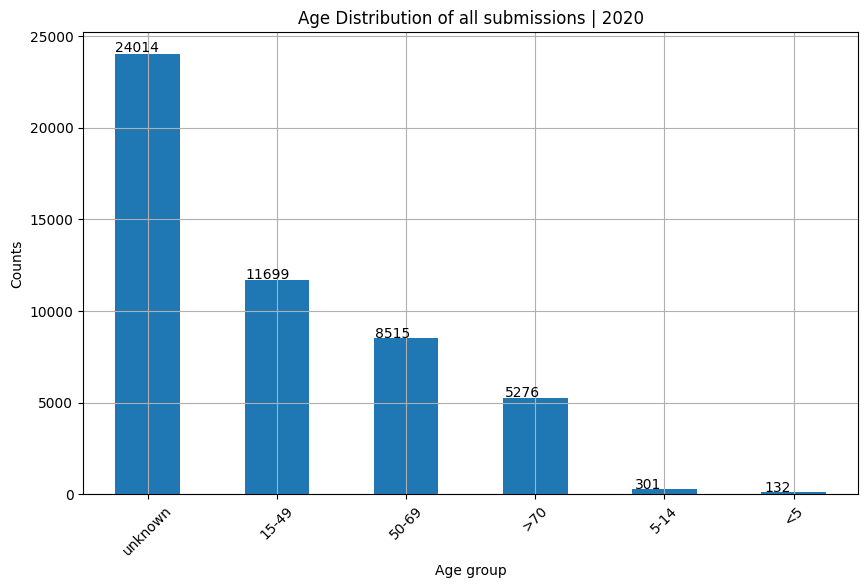

In [87]:
# Plot the bar chart
ax = df2["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title(f'Age Distribution of all submissions | {YEAR}')
plt.show()

In [88]:
import plotly.express as px

df_grouped = df2.groupby(["country", "age_group"]).size().reset_index(name="count")

df_grouped

,country,age_group,count
0,Algeria,15-49,8
1,Algeria,50-69,2
2,Algeria,>70,2
3,Andorra,<5,1
4,Argentina,15-49,16
...,...,...,...
450,Zambia,50-69,4
451,Zambia,>70,1
452,Zambia,unknown,3
453,Zimbabwe,15-49,7


In [89]:
fig = px.choropleth(
    df_grouped,
    locations="country",
    color="count",
    locationmode="country names",
    animation_frame="age_group",
    color_continuous_scale="YlGnBu",
    title=f"Age Group-wise Entries by Country | {YEAR}"
)
# Adjust the order of labels in the slider
# Desired order: '<5', '5-14', '15-49', '50-69', '>70', 'unknown'
desired_order = ['<5', '5-14', '15-49', '50-69', '>70', 'unknown']

# Find the current order of frames
current_order = [frame.name for frame in fig.frames]

# Create a mapping from label to frame
frame_dict = {frame.name: frame for frame in fig.frames}

# Reorder frames
fig.frames = tuple([frame_dict[label] for label in desired_order if label in frame_dict])

# Update slider steps order
for slider in fig.layout.sliders:
    step_dict = {step['label']: step for step in slider['steps']}
    slider['steps'] = [step_dict[label] for label in desired_order if label in step_dict]

fig.update_layout(title_x=0.5, width=1200, height=700)

fig.show()

In [90]:
fig = plot_dominant_choropleth(
    df2,
    value_column='age_group',
    color_map={
        '<5': '#e5f5e0',      # light green
        '5-14': '#a1d99b',
        '15-49': '#41ab5d',   # more contrast
        '50-69': '#238b45',   # more contrast
        '>70': '#005824',     # darkest green for high contrast
        'unknown': '#bdbdbd'  # gray for unknown
    },
    title="Dominant Age Group (Green Shades)"
    )
fig.show()

In [91]:
df_merged.columns

Index(['country', 'continent', 'population_2020', 'country_standard',
       'num_entries', 'num_entries_per_lakh', 'log_num_entries_per_lakh',
       'log_num_entries_per_lakh_filled', 'gender_m_per_lakh',
       'gender_f_per_lakh', 'gender_u_per_lakh', 'log_gender_m_per_lakh',
       'log_gender_m_per_lakh_filled', 'log_gender_f_per_lakh',
       'log_gender_f_per_lakh_filled', 'log_gender_u_per_lakh',
       'log_gender_u_per_lakh_filled', 'male_female_ratio',
       'male_female_ratio_filled', 'status_per_lakh', 'log_status_per_lakh',
       'log_status_per_lakh_filled'],
      dtype='object')

In [92]:
df_merged.groupby("continent").agg({"num_entries_per_lakh":"mean","gender_m_per_lakh":"mean","gender_f_per_lakh":"mean",
                                    "gender_u_per_lakh":"mean","male_female_ratio":"mean", "status_per_lakh":"mean",})

,num_entries_per_lakh,gender_m_per_lakh,gender_f_per_lakh,gender_u_per_lakh,male_female_ratio,status_per_lakh
continent,,,,,,
Africa,0.105425,0.048090,0.033025,0.024310,1.797072,0.012012
Antarctica,NaN,NaN,NaN,NaN,NaN,NaN
Asia,0.788325,0.387221,0.218753,0.182350,2.022197,0.006299
Europe,11.452692,4.916062,4.808750,1.727879,1.310924,0.157312
North America,3.134969,0.776920,1.189672,1.168377,1.178725,2.151969
Oceania,3.359390,1.146615,0.747420,1.465355,1.006954,0.185117
South America,1.044288,0.670577,0.283534,0.090177,1.457799,0.000496


### B. Normalising by country's GDP per capita

First, let us group each country by their GDP per capita into the following countries:
- Low Income (LI)
- Lower Middle Income (LMI)
- Upper Middle Income (UMI)
- High Income (MI)

In [93]:
ECO_PATH = os.path.expanduser(os.path.join(DATA_PATH, "National_Income_per_capita_till_2023"))
eco_files = os.listdir(ECO_PATH)
eco_files

['API_NY.ADJ.NNTY.PC.CD_DS2_en_csv_v2_16871.csv',
 'Metadata_Country_API_NY.ADJ.NNTY.PC.CD_DS2_en_csv_v2_16871.csv',
 'Metadata_Indicator_API_NY.ADJ.NNTY.PC.CD_DS2_en_csv_v2_16871.csv',
 'national_income_per_capita_2023.csv']

In [94]:
df_eco1 = pd.read_csv(os.path.join(ECO_PATH, eco_files[1]))
df_eco1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Code  265 non-null    object 
 1   Region        217 non-null    object 
 2   IncomeGroup   215 non-null    object 
 3   SpecialNotes  129 non-null    object 
 4   TableName     265 non-null    object 
 5   Unnamed: 5    0 non-null      float64
dtypes: float64(1), object(5)
memory usage: 12.6+ KB


In [95]:
df_eco1.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [96]:
df_eco1 = df_eco1[~df_eco1["IncomeGroup"].isnull()].drop(columns=["SpecialNotes","Unnamed: 5"])
df_eco1.rename(columns={"TableName":"country"},inplace=True)
df_eco1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 215 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Code  215 non-null    object
 1   Region        215 non-null    object
 2   IncomeGroup   215 non-null    object
 3   country       215 non-null    object
dtypes: object(4)
memory usage: 8.4+ KB


In [97]:
df_eco1.head()

,Country Code,Region,IncomeGroup,country
0,ABW,Latin America & Caribbean,High income,Aruba
2,AFG,Middle East & North Africa,Low income,Afghanistan
4,AGO,Sub-Saharan Africa,Lower middle income,Angola
5,ALB,Europe & Central Asia,Upper middle income,Albania
6,AND,Europe & Central Asia,High income,Andorra


In [98]:
len(set(df_merged["country"].values.tolist()).intersection(set(df_eco1["country"].values.tolist())))

179

In [99]:
set(df_merged["country"].values.tolist()) - (set(df_eco1["country"].values.tolist()))

{'Anguilla',
 'Antarctica',
 'Bonaire Sint Eustatius and Saba',
 'Brunei',
 'Cape Verde',
 'Congo',
 'Cook Islands',
 "Cote d'Ivoire",
 'Curacao',
 'Czech Republic',
 'Democratic Republic of Congo',
 'East Timor',
 'Egypt',
 'Ethiopia',
 'Falkland Islands',
 'French Guiana',
 'Gambia',
 'Guadeloupe',
 'Guernsey',
 'Hong Kong',
 'Iran',
 'Jersey',
 'Kyrgyzstan',
 'Laos',
 'Macao',
 'Martinique',
 'Mayotte',
 'Montserrat',
 'Niue',
 'North Korea',
 'Palestine',
 'Puerto Rico',
 'Reunion',
 'Russia',
 'Saint Barthelemy',
 'Saint Kitts and Nevis',
 'Saint Lucia',
 'Saint Martin',
 'Saint Pierre and Miquelon',
 'Saint Vincent and the Grenadines',
 'Sao Tome and Principe',
 'Slovakia',
 'South Korea',
 'Syria',
 'Taiwan',
 'Tokelau',
 'Turkey',
 'U.S. Virgin Islands',
 'Venezuela',
 'Vietnam',
 'Wallis and Futuna',
 'Yemen'}

In [100]:
df_eco2 = pd.read_csv(os.path.join(ECO_PATH, eco_files[0]), skiprows=4)
df_eco2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            73 non-null     float64
 15  1971            107 non-null    float64
 16  1972            107 non-null    float64
 17  1973            109 non-null    flo

In [101]:
df_eco2.drop(columns=[str(1960 + x) for x in range(10)] + ["2022", "2023", "2024", "Unnamed: 69"], inplace=True)
df_eco2.rename(columns={"Country Name":"country", "Country Code":"country_code"}, inplace=True)
df_eco2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 56 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         266 non-null    object 
 1   country_code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1970            73 non-null     float64
 5   1971            107 non-null    float64
 6   1972            107 non-null    float64
 7   1973            109 non-null    float64
 8   1974            109 non-null    float64
 9   1975            109 non-null    float64
 10  1976            112 non-null    float64
 11  1977            112 non-null    float64
 12  1978            112 non-null    float64
 13  1979            111 non-null    float64
 14  1980            153 non-null    float64
 15  1981            158 non-null    float64
 16  1982            158 non-null    float64
 17  1983            158 non-null    flo

In [102]:
df_eco = pd.merge(df_eco1, df_eco2, on="country", how="right")
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 59 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Code    210 non-null    object 
 1   Region          210 non-null    object 
 2   IncomeGroup     210 non-null    object 
 3   country         266 non-null    object 
 4   country_code    266 non-null    object 
 5   Indicator Name  266 non-null    object 
 6   Indicator Code  266 non-null    object 
 7   1970            73 non-null     float64
 8   1971            107 non-null    float64
 9   1972            107 non-null    float64
 10  1973            109 non-null    float64
 11  1974            109 non-null    float64
 12  1975            109 non-null    float64
 13  1976            112 non-null    float64
 14  1977            112 non-null    float64
 15  1978            112 non-null    float64
 16  1979            111 non-null    float64
 17  1980            153 non-null    flo

In [103]:
set(df_eco["country"].unique().tolist()) - set(df_eco1["country"].unique().tolist())

{'Africa Eastern and Southern',
 'Africa Western and Central',
 'Arab World',
 'Caribbean small states',
 'Central Europe and the Baltics',
 "Cote d'Ivoire",
 'Curacao',
 'Early-demographic dividend',
 'East Asia & Pacific',
 'East Asia & Pacific (IDA & IBRD countries)',
 'East Asia & Pacific (excluding high income)',
 'Ethiopia',
 'Euro area',
 'Europe & Central Asia',
 'Europe & Central Asia (IDA & IBRD countries)',
 'Europe & Central Asia (excluding high income)',
 'European Union',
 'Fragile and conflict affected situations',
 'Heavily indebted poor countries (HIPC)',
 'High income',
 'IBRD only',
 'IDA & IBRD total',
 'IDA blend',
 'IDA only',
 'IDA total',
 'Late-demographic dividend',
 'Latin America & Caribbean',
 'Latin America & Caribbean (excluding high income)',
 'Latin America & the Caribbean (IDA & IBRD countries)',
 'Least developed countries: UN classification',
 'Low & middle income',
 'Low income',
 'Lower middle income',
 'Middle East & North Africa',
 'Middle East &

In [104]:
len(set(df_eco1["country"].values.tolist()).intersection(set(df_eco2["country"].values.tolist())))

210

In [105]:
set(df_eco1["country"].values.tolist()) - (set(df_eco2["country"].values.tolist()))

{'Curaçao',
 "Côte d'Ivoire",
 'São Tomé and Principe',
 'Türkiye',
 'Virgin Islands (US)'}

In [106]:
[x for x in df_eco2["country"].values.tolist() if "Virgin" in x]

['British Virgin Islands', 'Virgin Islands (U.S.)']

In [107]:
df_eco1["country"] = df_eco1["country"].str.replace("Curaçao", "Curacao")
df_eco1["country"] = df_eco1["country"].str.replace("Côte d'Ivoire", "Cote d'Ivoire")
df_eco1["country"] = df_eco1["country"].str.replace("São Tomé and Principe", "Sao Tome and Principe")
df_eco1["country"] = df_eco1["country"].str.replace("Türkiye", "Turkiye")

In [108]:
df_eco2["country"] = df_eco2["country"].str.replace("Virgin Islands (U.S.)", "Virgin Islands (US)")

In [109]:
len(set(df_eco1["country"].values.tolist()).intersection(set(df_eco2["country"].values.tolist())))

215

In [110]:
df_eco = pd.merge(df_eco1, df_eco2, on="country", how="right")
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 59 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Code    215 non-null    object 
 1   Region          215 non-null    object 
 2   IncomeGroup     215 non-null    object 
 3   country         266 non-null    object 
 4   country_code    266 non-null    object 
 5   Indicator Name  266 non-null    object 
 6   Indicator Code  266 non-null    object 
 7   1970            73 non-null     float64
 8   1971            107 non-null    float64
 9   1972            107 non-null    float64
 10  1973            109 non-null    float64
 11  1974            109 non-null    float64
 12  1975            109 non-null    float64
 13  1976            112 non-null    float64
 14  1977            112 non-null    float64
 15  1978            112 non-null    float64
 16  1979            111 non-null    float64
 17  1980            153 non-null    flo

In [111]:
len(set(df_eco["country"].values.tolist()).intersection(set(df_merged["country"].values.tolist())))

183

In [112]:
len(set(df_eco["country"].values.tolist()).intersection(set(df2["country"].values.tolist())))

112

In [113]:
len(df2["country"].values.tolist()), len(df2["country"].unique().tolist())

(49937, 136)

In [114]:
set(df2["country"].values.tolist()) - (set(df_eco1["country"].values.tolist()))

{'Brunei',
 'Czech Republic',
 'Democratic Republic of Congo',
 'East Timor',
 'Egypt',
 'French Guiana',
 'Gambia',
 'Guadeloupe',
 'Hong Kong',
 'Iran',
 'Palestine',
 'Puerto Rico',
 'Reunion',
 'Russia',
 'Saint Barthelemy',
 'Saint Kitts and Nevis',
 'Saint Martin',
 'Slovakia',
 'South Korea',
 'Taiwan',
 'Turkey',
 'U.S. Virgin Islands',
 'Venezuela',
 'Vietnam'}

In [115]:
[x for x in df_eco1["country"].values.tolist() if "V" in x]

['Cabo Verde',
 'St. Vincent and the Grenadines',
 'British Virgin Islands',
 'Virgin Islands (US)',
 'Viet Nam',
 'Vanuatu']

In [116]:
df_eco["country"] = df_eco["country"].str.replace("Brunei Darussalam", "Brunei")
df_eco["country"] = df_eco["country"].str.replace("Czechia", "Czech Republic")
df_eco["country"] = df_eco["country"].str.replace("Congo, Dem. Rep.", "Democratic Republic of Congo")
df_eco["country"] = df_eco["country"].str.replace("Timor-Leste", "East Timor")
df_eco["country"] = df_eco["country"].str.replace("Egypt, Arab Rep.", "Egypt")
df_eco["country"] = df_eco["country"].str.replace("Gambia, The", "Gambia")
df_eco["country"] = df_eco["country"].str.replace("Hong Kong SAR, China", "Hong Kong")
df_eco["country"] = df_eco["country"].str.replace("Iran, Islamic Rep.", "Iran")
df_eco["country"] = df_eco["country"].str.replace("Puerto Rico (US)", "Puerto Rico")
df_eco["country"] = df_eco["country"].str.replace("Russian Federation", "Russia")
df_eco["country"] = df_eco["country"].str.replace("St. Kitts and Nevis", "Saint Kitts and Nevis")
df_eco["country"] = df_eco["country"].str.replace("St. Martin (French part)", "Saint Martin")
df_eco["country"] = df_eco["country"].str.replace("Slovak Republic", "Slovakia")
df_eco["country"] = df_eco["country"].str.replace("Korea, Rep.", "South Korea")
df_eco["country"] = df_eco["country"].str.replace("Turkiye", "Turkey")
df_eco["country"] = df_eco["country"].str.replace("Virgin Islands (US)", "U.S. Virgin Islands")
df_eco["country"] = df_eco["country"].str.replace("Viet Nam", "Vietnam")

In [117]:
focus = list(set(df2["country"].values.tolist()) - (set(df_eco["country"].values.tolist())))
df2[df2["country"].isin(focus)]["country"].value_counts()

country
Taiwan              110
Guadeloupe           23
Palestine            11
French Guiana         6
Venezuela             5
Reunion               3
Saint Barthelemy      2
Name: count, dtype: int64

In [118]:
len(focus)

7

In [119]:
df_eco[["country","2020","2021"]].head()

,country,2020,2021
0,Aruba,20584.791260,24724.866572
1,Africa Eastern and Southern,1098.092611,1214.873282
2,Afghanistan,475.718084,340.523244
3,Africa Western and Central,1374.444860,1393.442318
4,Angola,1100.217496,1231.925133


In [120]:
print(f'{len(set(df_eco["country"].values.tolist()).intersection(set(df2["country"].values.tolist())))}/{len(df2["country"].unique().tolist())} countries have economic data')
print(f'{len(set(df_eco["country"].values.tolist()).intersection(set(df_merged["country"].values.tolist())))}/{len(df_merged["country"].unique().tolist())} countries have economic data')

129/136 countries have economic data
200/231 countries have economic data


In [121]:
df_merged = pd.merge(df_merged, df_eco[["country", YEAR]], on="country", how="left")
df_merged.rename(columns={YEAR: f"nat_income_per_capita_{YEAR}"}, inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231 entries, 0 to 230
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          231 non-null    object 
 1   continent                        231 non-null    object 
 2   population_2020                  231 non-null    int64  
 3   country_standard                 231 non-null    object 
 4   num_entries                      136 non-null    float64
 5   num_entries_per_lakh             136 non-null    float64
 6   log_num_entries_per_lakh         136 non-null    float64
 7   log_num_entries_per_lakh_filled  231 non-null    float64
 8   gender_m_per_lakh                136 non-null    float64
 9   gender_f_per_lakh                136 non-null    float64
 10  gender_u_per_lakh                136 non-null    float64
 11  log_gender_m_per_lakh            115 non-null    float64
 12  log_gender_m_per_lakh_

In [122]:
match = list(set(df_merged["country"].values.tolist()).intersection(set(df_eco["country"].values.tolist())))
df__1 = df_merged[(df_merged["country"].isin(match)) & (df_merged[f"nat_income_per_capita_{YEAR}"].isnull())][["country", f"nat_income_per_capita_{YEAR}"]]
df_eco[df_eco["country"].isin(df__1["country"].unique().tolist())][["country", "2020", "2021"]]

,country,2020,2021
6,Andorra,NaN,NaN
11,American Samoa,NaN,NaN
12,Antigua and Barbuda,NaN,NaN
27,Bermuda,NaN,NaN
50,Cuba,NaN,NaN
51,Curacao,NaN,NaN
52,Cayman Islands,NaN,NaN
69,Eritrea,NaN,NaN
78,Faroe Islands,NaN,NaN
81,United Kingdom,NaN,NaN


In [123]:
mix = list(set(df__1["country"].values.tolist()).intersection(set(df2["country"].values.tolist())))
df2[df2["country"].isin(mix)]["country"].value_counts()

country
United Kingdom           8501
Hong Kong                 454
Cuba                       18
Faroe Islands              14
Puerto Rico                14
Kuwait                     11
U.S. Virgin Islands         6
Curacao                     6
Guam                        4
Saint Martin                2
Andorra                     1
Saint Kitts and Nevis       1
Name: count, dtype: int64

Major chunk of entries are missing `National_income` data. We check which ones have good amount of data to atleast predict the value at the required time points. We use time series models (statistical or ML) to do this prediction.

In [124]:
df_eco[df_eco["country"].isin(mix)]

,Country Code,Region,IncomeGroup,country,country_code,Indicator Name,Indicator Code,1970,1971,1972,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
6,AND,Europe & Central Asia,High income,Andorra,AND,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,CUB,Latin America & Caribbean,Upper middle income,Cuba,CUB,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,575.671812,687.367376,795.886038,...,5495.469329,5830.573378,6107.338454,6645.266827,6957.900384,7366.416254,7586.049674,7891.258815,NaN,NaN
51,CUW,Latin America & Caribbean,High income,Curacao,CUW,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,FRO,Europe & Central Asia,High income,Faroe Islands,FRO,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,GBR,Europe & Central Asia,High income,United Kingdom,GBR,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,2267.450040,2534.270487,2881.707738,...,35513.317481,36079.910719,39528.285153,37457.261032,34106.744384,34113.844890,36165.903933,NaN,NaN,NaN
93,GUM,East Asia & Pacific,High income,Guam,GUM,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,HKG,East Asia & Pacific,High income,Hong Kong,HKG,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,KNA,Latin America & Caribbean,High income,Saint Kitts and Nevis,KNA,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,KWT,Middle East & North Africa,High income,Kuwait,KWT,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,2210.940577,2649.457348,2457.637631,...,43810.642209,42999.994362,39694.157348,27811.712906,25708.132151,28379.076646,30000.681581,29080.106217,NaN,NaN
147,MAF,Latin America & Caribbean,High income,Saint Martin,MAF,Adjusted net national income per capita (curre...,NY.ADJ.NNTY.PC.CD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We see that `Cuba`, `United Kingdom` and `Kuwait` have historical values for National Income per capita. We can use these series to get the values for the years `2020` and `2021`.

In [125]:
# df_eco.to_csv(os.path.join(ECO_PATH, "national_income_per_capita_2023.csv"), index=False)

In [126]:
df2["country"].to_csv(os.path.join(DATA_PATH, "countries_2020.csv"), index=False)